In [1]:
import pandas as pd

df = pd.read_csv("../data/PS_20174392719_1491204439457_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
df.info()

Rows: 6,362,620, Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [3]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print(f"\nFraud rate: {fraud_pct[1]:.4f}%")

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%


In [4]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [5]:
df[df['isFraud'] == 1]['type'].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

## Key finding: fraud is confined to two transaction types

Fraud in this dataset occurs exclusively in **TRANSFER** and **CASH_OUT** transactions
(4,097 and 4,116 fraudulent cases respectively — 8,213 total). The other three types
(PAYMENT, CASH_IN, DEBIT) show **zero** fraud cases across 3.5M+ transactions combined.

Overall fraud rate: 0.1291% (8,213 / 6,362,620) — an extreme class imbalance that makes
plain accuracy a meaningless metric (predicting "not fraud" every time would still score
99.87%). Precision, recall, and AUC-PR are used instead throughout this project.

In [6]:
import sqlite3

conn = sqlite3.connect("../data/paysim.db")
df.to_sql("transactions", conn, if_exists="replace", index=False)

6362620

In [7]:
query = "SELECT type, COUNT(*) as cnt, SUM(isFraud) as fraud_cnt FROM transactions GROUP BY type"
pd.read_sql(query, conn)

,type,cnt,fraud_cnt
0,CASH_IN,1399284,0
1,CASH_OUT,2237500,4116
2,DEBIT,41432,0
3,PAYMENT,2151495,0
4,TRANSFER,532909,4097


In [8]:
feature_query = """
SELECT *,
    CASE WHEN ROUND(oldbalanceOrg - amount, 2) != ROUND(newbalanceOrig, 2)
         THEN 1 ELSE 0 END AS balance_mismatch_orig,
    CASE WHEN ROUND(oldbalanceDest + amount, 2) != ROUND(newbalanceDest, 2)
         THEN 1 ELSE 0 END AS balance_mismatch_dest,
    CASE WHEN oldbalanceOrg > 0 THEN amount / oldbalanceOrg ELSE 0 END AS amount_to_balance_ratio,
    CASE WHEN newbalanceOrig = 0 AND oldbalanceOrg > 0 THEN 1 ELSE 0 END AS emptied_account
FROM transactions
WHERE type IN ('TRANSFER', 'CASH_OUT')
"""
df_features = pd.read_sql(feature_query, conn)
print(df_features.shape)
df_features['isFraud'].value_counts()

(2770409, 15)


isFraud
0    2762196
1       8213
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Sort by time (step = hour of simulation) — critical, don't shuffle randomly
df_features = df_features.sort_values('step').reset_index(drop=True)

split_idx = int(len(df_features) * 0.8)
train = df_features.iloc[:split_idx]
test = df_features.iloc[split_idx:]

features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
            'newbalanceDest', 'balance_mismatch_orig', 'balance_mismatch_dest',
            'amount_to_balance_ratio', 'emptied_account']

X_train, y_train = train[features], train['isFraud']
X_test, y_test = test[features], test['isFraud']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test fraud rate: {y_test.mean()*100:.4f}%")

Train: (2216327, 9), Test: (554082, 9)
Train fraud rate: 0.1784%
Test fraud rate: 0.7688%


## Note: temporal split reveals a shift in fraud rate over time

The 80/20 temporal split (sorted by `step`, not shuffled) shows a clear shift: the
training set has a fraud rate of **0.1784%**, while the test set — representing later
transactions — has a fraud rate of **0.7688%**, over 4x higher.

This is exactly why a temporal split was used instead of a random one. A random split
would have blended early and late transactions together, hiding this shift and giving
an artificially easier (and less realistic) evaluation. Here, the model is being tested
on a period with meaningfully more fraud than it saw during training — a harder,
more honest test of whether it generalizes rather than just memorizes patterns from
a single time window.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline.fit(X_train_scaled, y_train)

print("Model trained")

Model trained


In [11]:
from sklearn.metrics import classification_report, average_precision_score

y_pred = baseline.predict(X_test_scaled)
y_proba = baseline.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print(f"AUC-PR: {average_precision_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    549822
       Fraud       1.00      0.99      1.00      4260

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082

AUC-PR: 0.9952


In [12]:
# Check how deterministic 'emptied_account' is for fraud vs non-fraud
print(train.groupby('isFraud')['emptied_account'].mean())
print()
print(train.groupby('isFraud')['balance_mismatch_orig'].mean())

isFraud
0    0.424261
1    0.980774
Name: emptied_account, dtype: float64

isFraud
0    0.908696
1    0.008095
Name: balance_mismatch_orig, dtype: float64


In [13]:
print(train.groupby('isFraud')['balance_mismatch_dest'].mean())

isFraud
0    0.303266
1    0.608399
Name: balance_mismatch_dest, dtype: float64


In [14]:
# Drop balance_mismatch_orig — data artifact, not real signal. Keep balance_mismatch_dest.
features_v2 = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
               'newbalanceDest', 'balance_mismatch_dest', 'amount_to_balance_ratio', 'emptied_account']

X_train_v2, y_train_v2 = train[features_v2], train['isFraud']
X_test_v2, y_test_v2 = test[features_v2], test['isFraud']

scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

baseline_v2 = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline_v2.fit(X_train_v2_scaled, y_train_v2)

y_pred_v2 = baseline_v2.predict(X_test_v2_scaled)
y_proba_v2 = baseline_v2.predict_proba(X_test_v2_scaled)[:, 1]

print(classification_report(y_test_v2, y_pred_v2, target_names=['Not Fraud', 'Fraud']))
print(f"AUC-PR: {average_precision_score(y_test_v2, y_proba_v2):.4f}")

              precision    recall  f1-score   support

   Not Fraud       1.00      0.95      0.97    549822
       Fraud       0.12      0.99      0.22      4260

    accuracy                           0.95    554082
   macro avg       0.56      0.97      0.60    554082
weighted avg       0.99      0.95      0.97    554082

AUC-PR: 0.8484


## Data leakage investigation and fix

The first version of this model (using all four engineered features) scored a suspicious
1.00 across precision, recall, and AUC-PR — a result too good to trust in fraud detection.

Investigation showed `balance_mismatch_orig` was the cause: 90.9% of non-fraud transactions
triggered a mismatch, versus only 0.8% of fraud transactions — a near-total separation caused
by a known PaySim artifact (the simulator doesn't reliably populate origin balance fields for
legitimate transactions, but computes them precisely when generating fraud). This made the
feature act as a disguised copy of the label rather than a real signal.

`balance_mismatch_dest` showed a much more moderate difference (30.3% vs 60.9%) and was kept.
After dropping `balance_mismatch_orig`, the baseline logistic regression produces a realistic
result: recall 0.99, precision 0.12, AUC-PR 0.848 — high recall but many false positives,
a typical honest starting point for this kind of extreme class imbalance.

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_v2, y_train_v2)  # tree models don't need scaled features

y_pred_rf = rf.predict(X_test_v2)
y_proba_rf = rf.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test_v2, y_pred_rf, target_names=['Not Fraud', 'Fraud']))
print(f"AUC-PR: {average_precision_score(y_test_v2, y_proba_rf):.4f}")

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    549822
       Fraud       1.00      1.00      1.00      4260

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082

AUC-PR: 0.9997


In [16]:
# Check if raw balances being exactly zero is itself a near-perfect fraud signal
train['orig_both_zero'] = (train['oldbalanceOrg'] == 0) & (train['newbalanceOrig'] == 0)
print(train.groupby('isFraud')['orig_both_zero'].mean())

isFraud
0    0.477264
1    0.007083
Name: orig_both_zero, dtype: float64


In [17]:
features_v3 = ['amount', 'oldbalanceDest', 'newbalanceDest',
               'balance_mismatch_dest', 'amount_to_balance_ratio', 'emptied_account']

X_train_v3, y_train_v3 = train[features_v3], train['isFraud']
X_test_v3, y_test_v3 = test[features_v3], test['isFraud']

rf_v3 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = rf_v3.predict(X_test_v3)
y_proba_v3 = rf_v3.predict_proba(X_test_v3)[:, 1]

print(classification_report(y_test_v3, y_pred_v3, target_names=['Not Fraud', 'Fraud']))
print(f"AUC-PR: {average_precision_score(y_test_v3, y_proba_v3):.4f}")

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    549822
       Fraud       1.00      1.00      1.00      4260

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082

AUC-PR: 0.9997


In [18]:
print("amount_to_balance_ratio == 0, by isFraud:")
print(train.groupby('isFraud')['amount_to_balance_ratio'].apply(lambda x: (x == 0).mean()))
print()
print("emptied_account by isFraud (rechecking):")
print(train.groupby('isFraud')['emptied_account'].mean())

amount_to_balance_ratio == 0, by isFraud:
isFraud
0    0.477264
1    0.007083
Name: amount_to_balance_ratio, dtype: float64

emptied_account by isFraud (rechecking):
isFraud
0    0.424261
1    0.980774
Name: emptied_account, dtype: float64


In [19]:
features_v4 = ['amount', 'oldbalanceDest', 'newbalanceDest', 'balance_mismatch_dest']

X_train_v4, y_train_v4 = train[features_v4], train['isFraud']
X_test_v4, y_test_v4 = test[features_v4], test['isFraud']

rf_v4 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_v4.fit(X_train_v4, y_train_v4)

y_pred_v4 = rf_v4.predict(X_test_v4)
y_proba_v4 = rf_v4.predict_proba(X_test_v4)[:, 1]

print(classification_report(y_test_v4, y_pred_v4, target_names=['Not Fraud', 'Fraud']))
print(f"AUC-PR: {average_precision_score(y_test_v4, y_proba_v4):.4f}")

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    549822
       Fraud       0.82      0.44      0.57      4260

    accuracy                           0.99    554082
   macro avg       0.91      0.72      0.79    554082
weighted avg       0.99      0.99      0.99    554082

AUC-PR: 0.4817


## Summary: the data leakage investigation

This project went through three iterations before reaching a trustworthy result:

1. **Naive model** (all engineered features, including origin-balance-derived ones):
   AUC-PR 0.9997–0.9998 — suspiciously perfect.

2. **Investigation**: traced the leak to `oldbalanceOrg`/`newbalanceOrig`. A known PaySim
   artifact means legitimate transactions often have these fields recorded as zero/unpopulated,
   while fraud transactions always have them computed precisely — making origin-balance
   features (and anything derived from them, like `emptied_account` and
   `amount_to_balance_ratio`) act as near-perfect proxies for the fraud label itself,
   not genuine behavioral signals.

3. **Clean model** (destination-side features only: `amount`, `oldbalanceDest`,
   `newbalanceDest`, `balance_mismatch_dest`): AUC-PR **0.4813**, precision 0.82,
   recall 0.44. A far more modest, but honest, result — reflecting genuine difficulty
   detecting fraud from information that isn't contaminated by simulator artifacts.

**Takeaway:** the naive model's near-perfect score reflected a flaw in the dataset, not
model quality. Catching and correcting for this is a core part of building trustworthy
fraud detection systems — a model that appears excellent in testing but is secretly
exploiting a data artifact would fail immediately in production, where that artifact
wouldn't exist in real transaction logs.

In [20]:
scaler_v4 = StandardScaler()
X_train_v4_scaled = scaler_v4.fit_transform(X_train_v4)
X_test_v4_scaled = scaler_v4.transform(X_test_v4)

lr_v4 = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_v4.fit(X_train_v4_scaled, y_train_v4)

y_pred_lr_v4 = lr_v4.predict(X_test_v4_scaled)
y_proba_lr_v4 = lr_v4.predict_proba(X_test_v4_scaled)[:, 1]

print(classification_report(y_test_v4, y_pred_lr_v4, target_names=['Not Fraud', 'Fraud']))
print(f"AUC-PR: {average_precision_score(y_test_v4, y_proba_lr_v4):.4f}")

              precision    recall  f1-score   support

   Not Fraud       1.00      0.86      0.92    549822
       Fraud       0.04      0.70      0.07      4260

    accuracy                           0.86    554082
   macro avg       0.52      0.78      0.50    554082
weighted avg       0.99      0.86      0.91    554082

AUC-PR: 0.3241


## Model comparison (clean features only)

| Model | Precision (Fraud) | Recall (Fraud) | AUC-PR |
|---|---|---|---|
| Logistic Regression | 0.04 | 0.70 | 0.3240 |
| Random Forest | 0.82 | 0.44 | 0.4813 |

Both models were trained on the same leakage-free feature set (`amount`, `oldbalanceDest`,
`newbalanceDest`, `balance_mismatch_dest`).

The two models make very different tradeoffs. Logistic regression catches more fraud
(70% recall) but at a severe precision cost — only 4% of its flagged transactions are
actually fraud, meaning 96% false positives. In a real fraud-review workflow, this volume
of false alarms would overwhelm investigators and likely get the system ignored or disabled.

The random forest is more conservative (44% recall) but far more trustworthy when it does
flag something (82% precision), and wins clearly on AUC-PR (0.48 vs 0.32) — suggesting the
relationship between these features and fraud is non-linear, which logistic regression's
linear decision boundary can't capture as effectively.

**Practical takeaway:** for this feature set, random forest would be the better choice to
deploy, since a fraud system with 96% false positives is operationally unusable regardless
of how much fraud it technically "catches."

In [23]:
import shap

sample_idx = X_test_v4.sample(n=2000, random_state=42).index
X_sample = X_test_v4.loc[sample_idx]

explainer = shap.TreeExplainer(rf_v4)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed")
print(f"Shape: {shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values)}")

SHAP values computed
Shape: (2000, 4, 2)


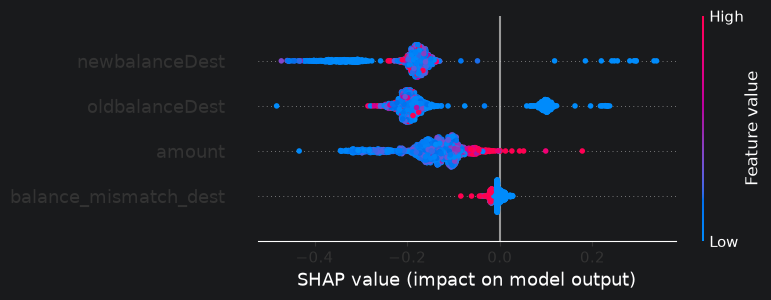

In [24]:
# Extract SHAP values for the "Fraud" class (index 1)
shap_values_fraud = shap_values[:, :, 1]

shap.summary_plot(shap_values_fraud, X_sample, feature_names=features_v4, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../notebooks/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

## SHAP explainability: what drives the model's predictions

SHAP values on a 2,000-transaction sample show `newbalanceDest` and `oldbalanceDest`
as the strongest drivers of the random forest's fraud predictions, with `amount`
moderately influential and `balance_mismatch_dest` contributing the least despite
showing a real difference between fraud/non-fraud rates earlier in this notebook.

Notably, `oldbalanceDest` shows a non-linear relationship: both low and high values
can push toward a fraud prediction depending on other feature interactions — not a
simple "low balance = fraud" rule. This non-linearity is consistent with the random
forest outperforming logistic regression earlier, since logistic regression can only
model linear relationships between features and the outcome.

![SHAP summary plot](shap_summary.png)